#### 移動の無駄と停滞エリアの比較

* どこで時間を消費しているか？
* 農家や労働者がどこで最も時間を消費しているか？

#### 特徴量

`["farmer_x_y"]` 自分の座標<br>
`["hands_list_1"]` 労働者1座標<br>
.<br>
.<br>
`["hands_list_20"]` 労働者20座標<br>
`["unlocked_quadrants"]` アンロックした土地<br>

#### グラフ
2Dヒートマップ (2D Heatmap)
2Dカーネル密度推定 (2D KDE Plot)



In [ ]:
!unzip -qo /content/output_re.zip -d /data

In [ ]:
import pandas as pd
from kaggriculture_df import Kaggriculture_df


import ast


#1
def convert(val):
    """
    文字列の "[4, 4]" などを、リストの [4, 4] に変換

    """
    if isinstance(val, str):
        return ast.literal_eval(val)
    else:
        return val


import seaborn as sns
import matplotlib.pyplot as plt
import math


#2
def xy_plt_2d(df):
    """
    df[""]をヒートマップに変換：単体

    <df>:2D配列のdf[x,y]
    """
    df = df.apply(convert)
    df_xy = pd.DataFrame(df.tolist(), columns=["x", "y"])
    df_xy = df_xy.dropna().astype(int)
    heatmap_data = pd.crosstab(df_xy['y'], df_xy['x'])
    grid_range = list(range(10))
    heatmap_data = heatmap_data.reindex(
        index=grid_range, columns=grid_range, fill_value=0
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(heatmap_data, annot=True, cmap="Blues", fmt="d")
    plt.show()


#3
def xy_plt_2d_all(df, cols, n_rows, n_cols):
    """
    df[""]をヒートマップに変換：複数

    <df>:2D配列のdf[x,y]

    xy_plt_2d_all(df_st, ["<列>", "<列>"], <行の数>, <列の数>)
    """
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
    axes = axes.flatten()

    grid_range = list(range(10))

    for i, col in enumerate(cols):
        ax = axes[i]

        s = df[col].apply(convert)
        df_xy = pd.DataFrame(s.tolist(), columns=["x", "y"])
        df_xy = df_xy.dropna().astype(int)
        heatmap_data = pd.crosstab(df_xy['y'], df_xy['x'])

        heatmap_data = heatmap_data.reindex(
            index=grid_range, columns=grid_range, fill_value=0
        )



        sns.heatmap(heatmap_data, annot=True, cmap="Blues", fmt="d", ax=ax, cbar=False)
        ax.set_title(col)

    plt.tight_layout()
    plt.show()

#4
def extract_df(filepath, num):
    df_all = Kaggriculture_df(filepath, num).df
    hands_cols = [f"hands_list_{i}" for i in range(1, 18)]
    return df_all[["farmer_x_y", "unlocked_quadrants"] + hands_cols].copy()


df_st = (Kaggriculture_df("/data/st_data/strong_rank1_score157577.0_p1.json", 1)).df
df_be = (Kaggriculture_df("/data/be_data/beginner_rank1_score83174.0_p1.json",1)).df



# スコアが一番高かったプレイヤーの動き

* DF作成

In [ ]:
df_st

,step,day,money,tiles,farmer_x_y,hands_n,hires_today,unlocked_quadrants,private_shed,private_seeds,...,hands_action_list_11,hands_action_list_12,hands_action_list_13,hands_action_list_14,hands_action_list_15,hands_action_list_16,hands_action_list_17,hands_action_list_18,hands_action_list_19,hands_action_list_20
0,0,0,3000.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",0,0,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
1,1,0,22.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 2, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
2,2,0,50.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 2, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
3,3,0,22.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
4,4,0,50.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[3, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,715,29,144726.0,"[[None, None, None, None, None, None, {'consec...","[5, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]
716,716,29,146959.0,"[[None, None, None, None, None, None, {'consec...","[5, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]
717,717,29,156142.0,"[[None, None, None, None, None, None, {'consec...","[4, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]
718,718,29,157185.0,"[[None, None, None, None, None, None, {'consec...","[4, 4]",11,11,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[SOUTH],[None],[None],[None],[None],[None],[None],[None],[None],[None]


In [ ]:
df_be

,step,day,money,tiles,farmer_x_y,hands_n,hires_today,unlocked_quadrants,private_shed,private_seeds,...,hands_action_list_11,hands_action_list_12,hands_action_list_13,hands_action_list_14,hands_action_list_15,hands_action_list_16,hands_action_list_17,hands_action_list_18,hands_action_list_19,hands_action_list_20
0,0,0,3000.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",0,0,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
1,1,0,22.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 2, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
2,2,0,50.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 2, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
3,3,0,22.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[4, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
4,4,0,50.0,"[[None, None, None, None, None, LOCKED, LOCKED...","[3, 4]",5,5,[NW],"{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 12, 'STRAWBERRY': 0, 'T...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,715,29,77590.0,"[[{'consecutive_unwatered': 0, 'crop': 'WHEAT'...","[5, 4]",10,10,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
716,716,29,79351.0,"[[{'consecutive_unwatered': 0, 'crop': 'WHEAT'...","[5, 4]",10,10,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
717,717,29,82589.0,"[[{'consecutive_unwatered': 0, 'crop': 'WHEAT'...","[5, 4]",10,10,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]
718,718,29,83084.0,"[[{'consecutive_unwatered': 0, 'crop': 'WHEAT'...","[5, 4]",10,10,"[NW, NE, SW]","{'CARROT': 0, 'COW': 0, 'EGG': 0, 'FERTILIZER'...","{'CARROT': 0, 'MELON': 0, 'STRAWBERRY': 0, 'TO...",...,[None],[None],[None],[None],[None],[None],[None],[None],[None],[None]


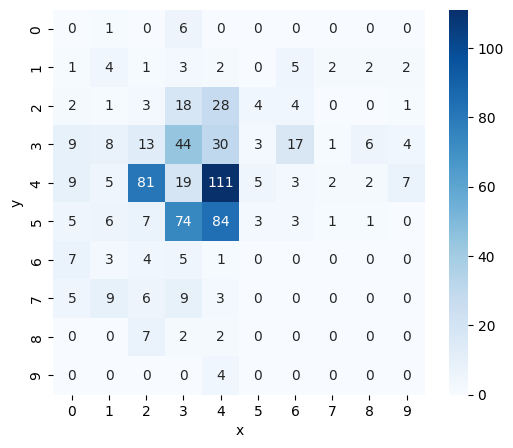

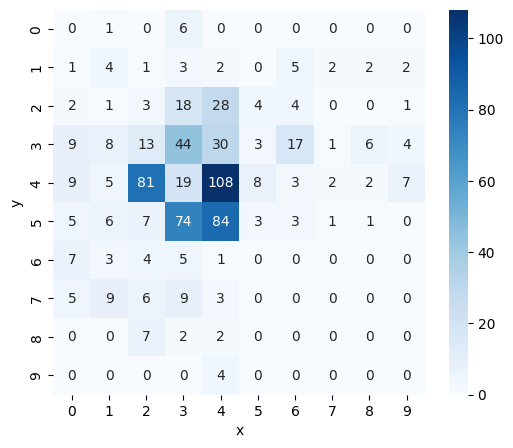

In [ ]:
xy_plt_2d(df_st["farmer_x_y"])
xy_plt_2d(df_be["farmer_x_y"])

In [ ]:
is_same_data = df_st["farmer_x_y"].equals(df_be["farmer_x_y"])

print(f"df_st[farmer_x_y]とdf_be[farmer_x_y]のデータは完全に同じか？: {is_same_data}")

df_st[farmer_x_y]とdf_be[farmer_x_y]のデータは完全に同じか？: False


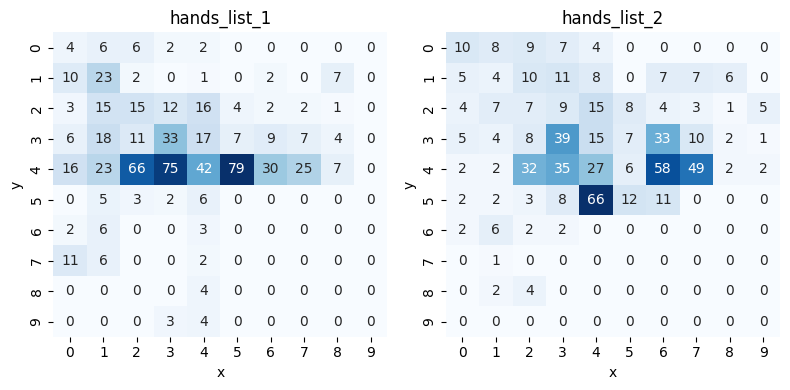

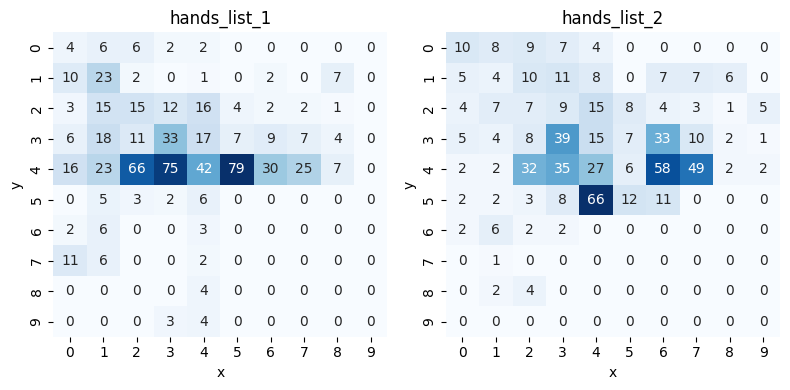

In [ ]:
xy_plt_2d_all(df_st, ["hands_list_1", "hands_list_2"], 1, 2)
xy_plt_2d_all(df_be, ["hands_list_1", "hands_list_2"], 1, 2)

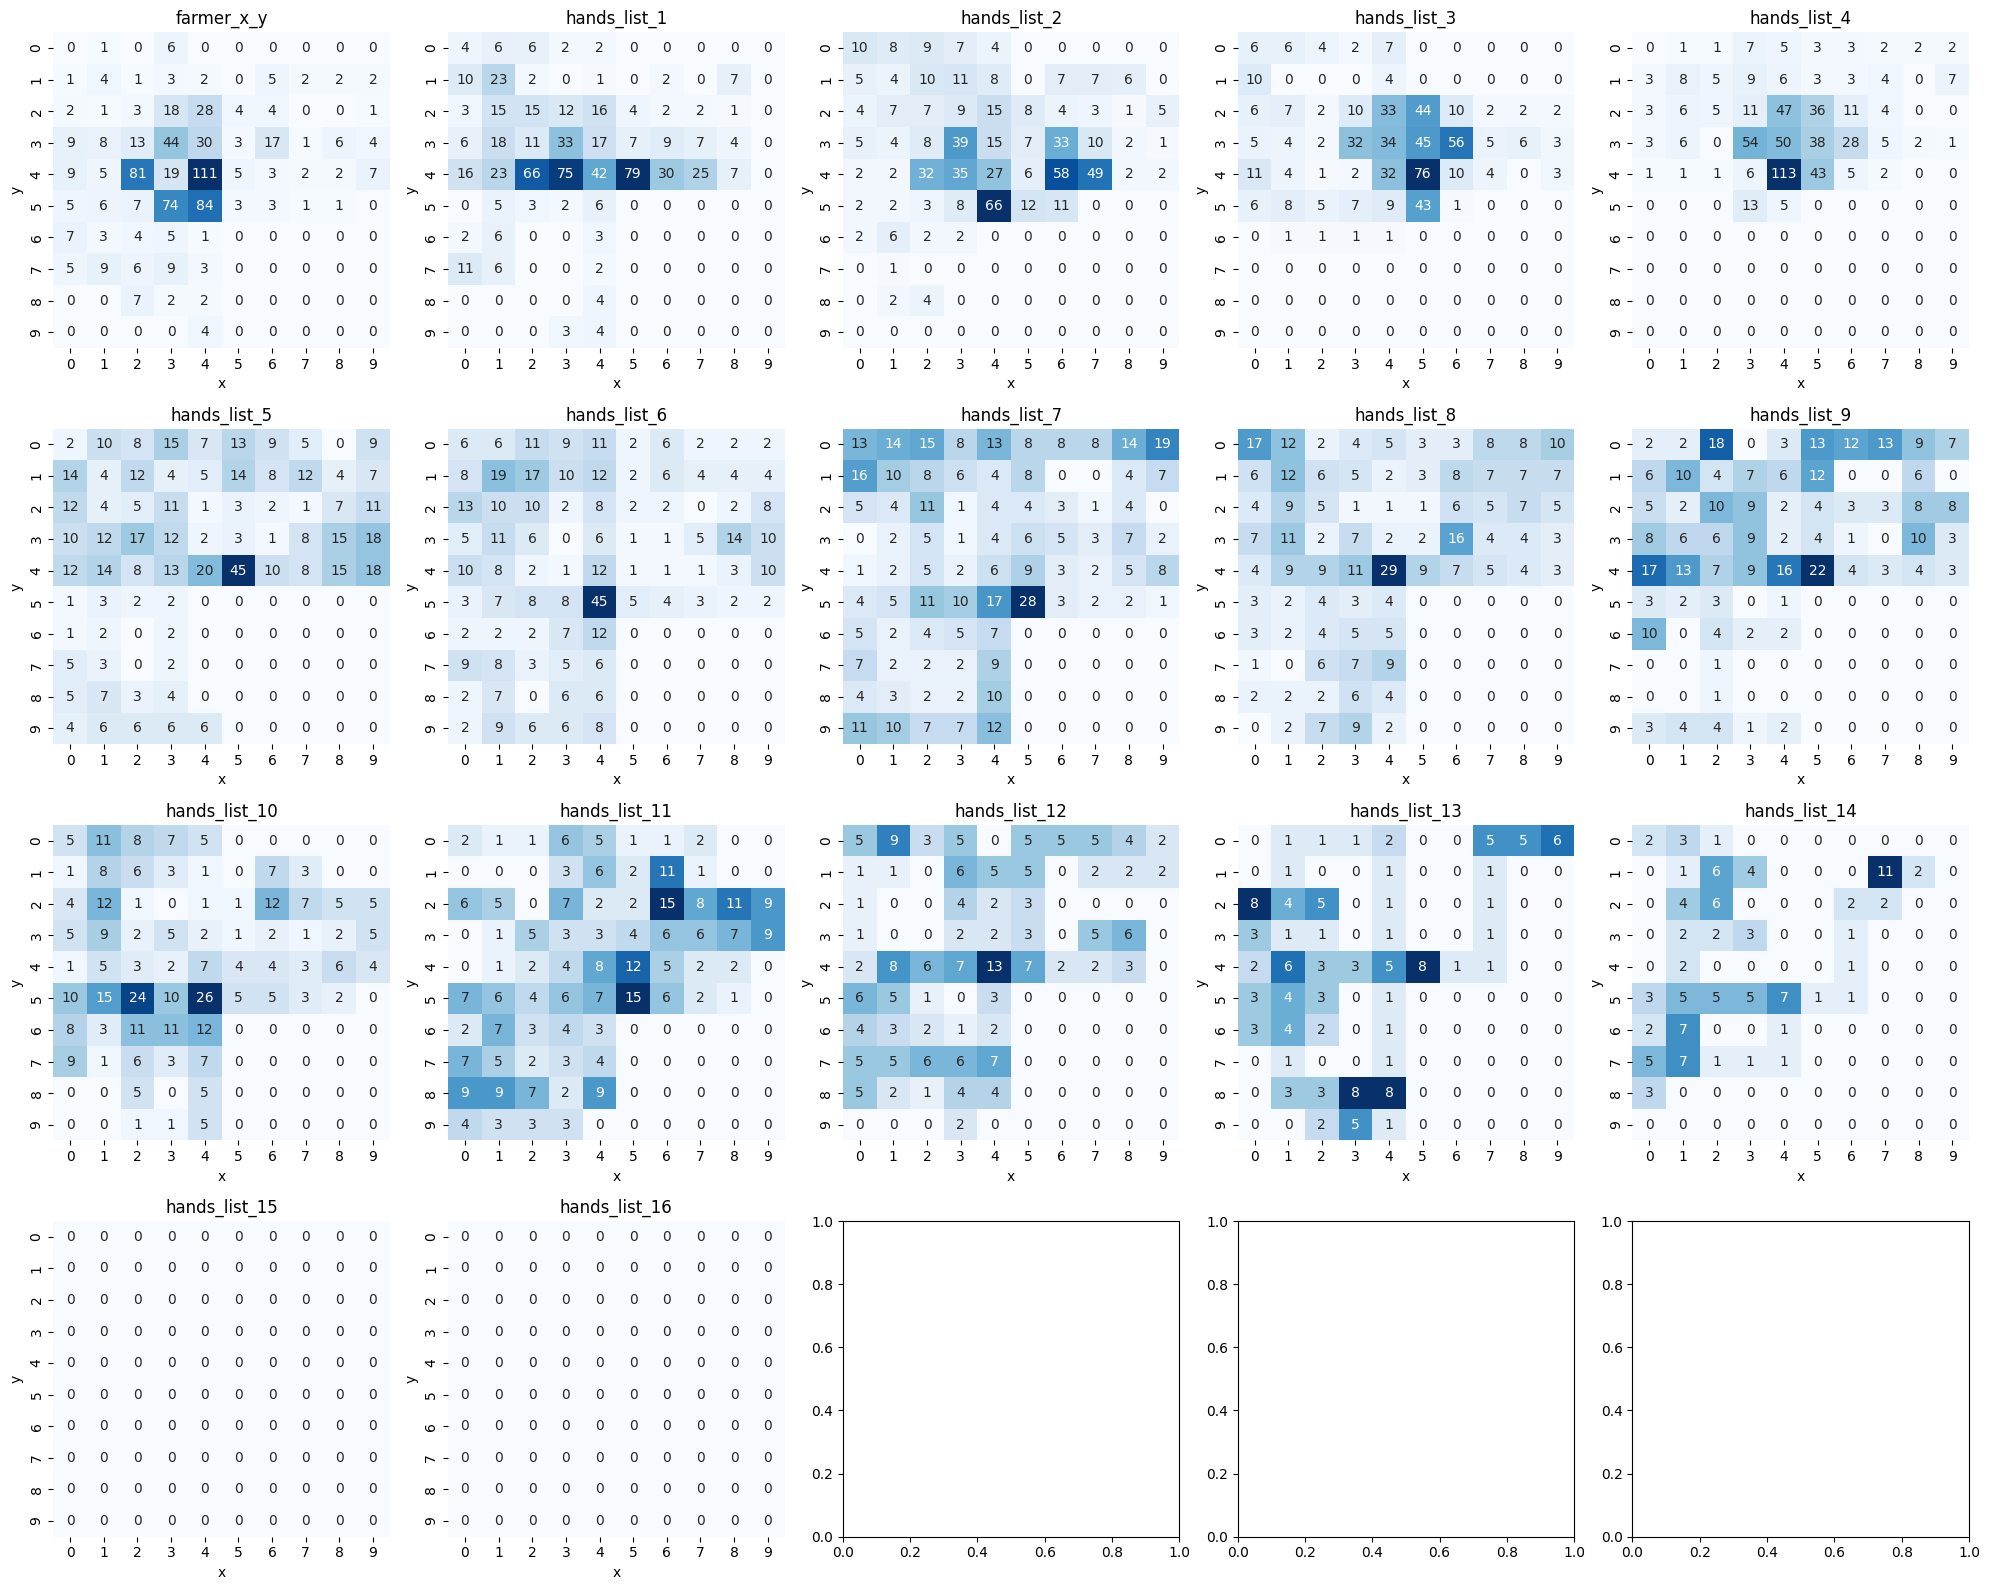

In [ ]:
cols_st = ["farmer_x_y"] + [f"hands_list_{i}" for i in range(1, 17)]
xy_plt_2d_all(df_st, cols_st, 4, 5)

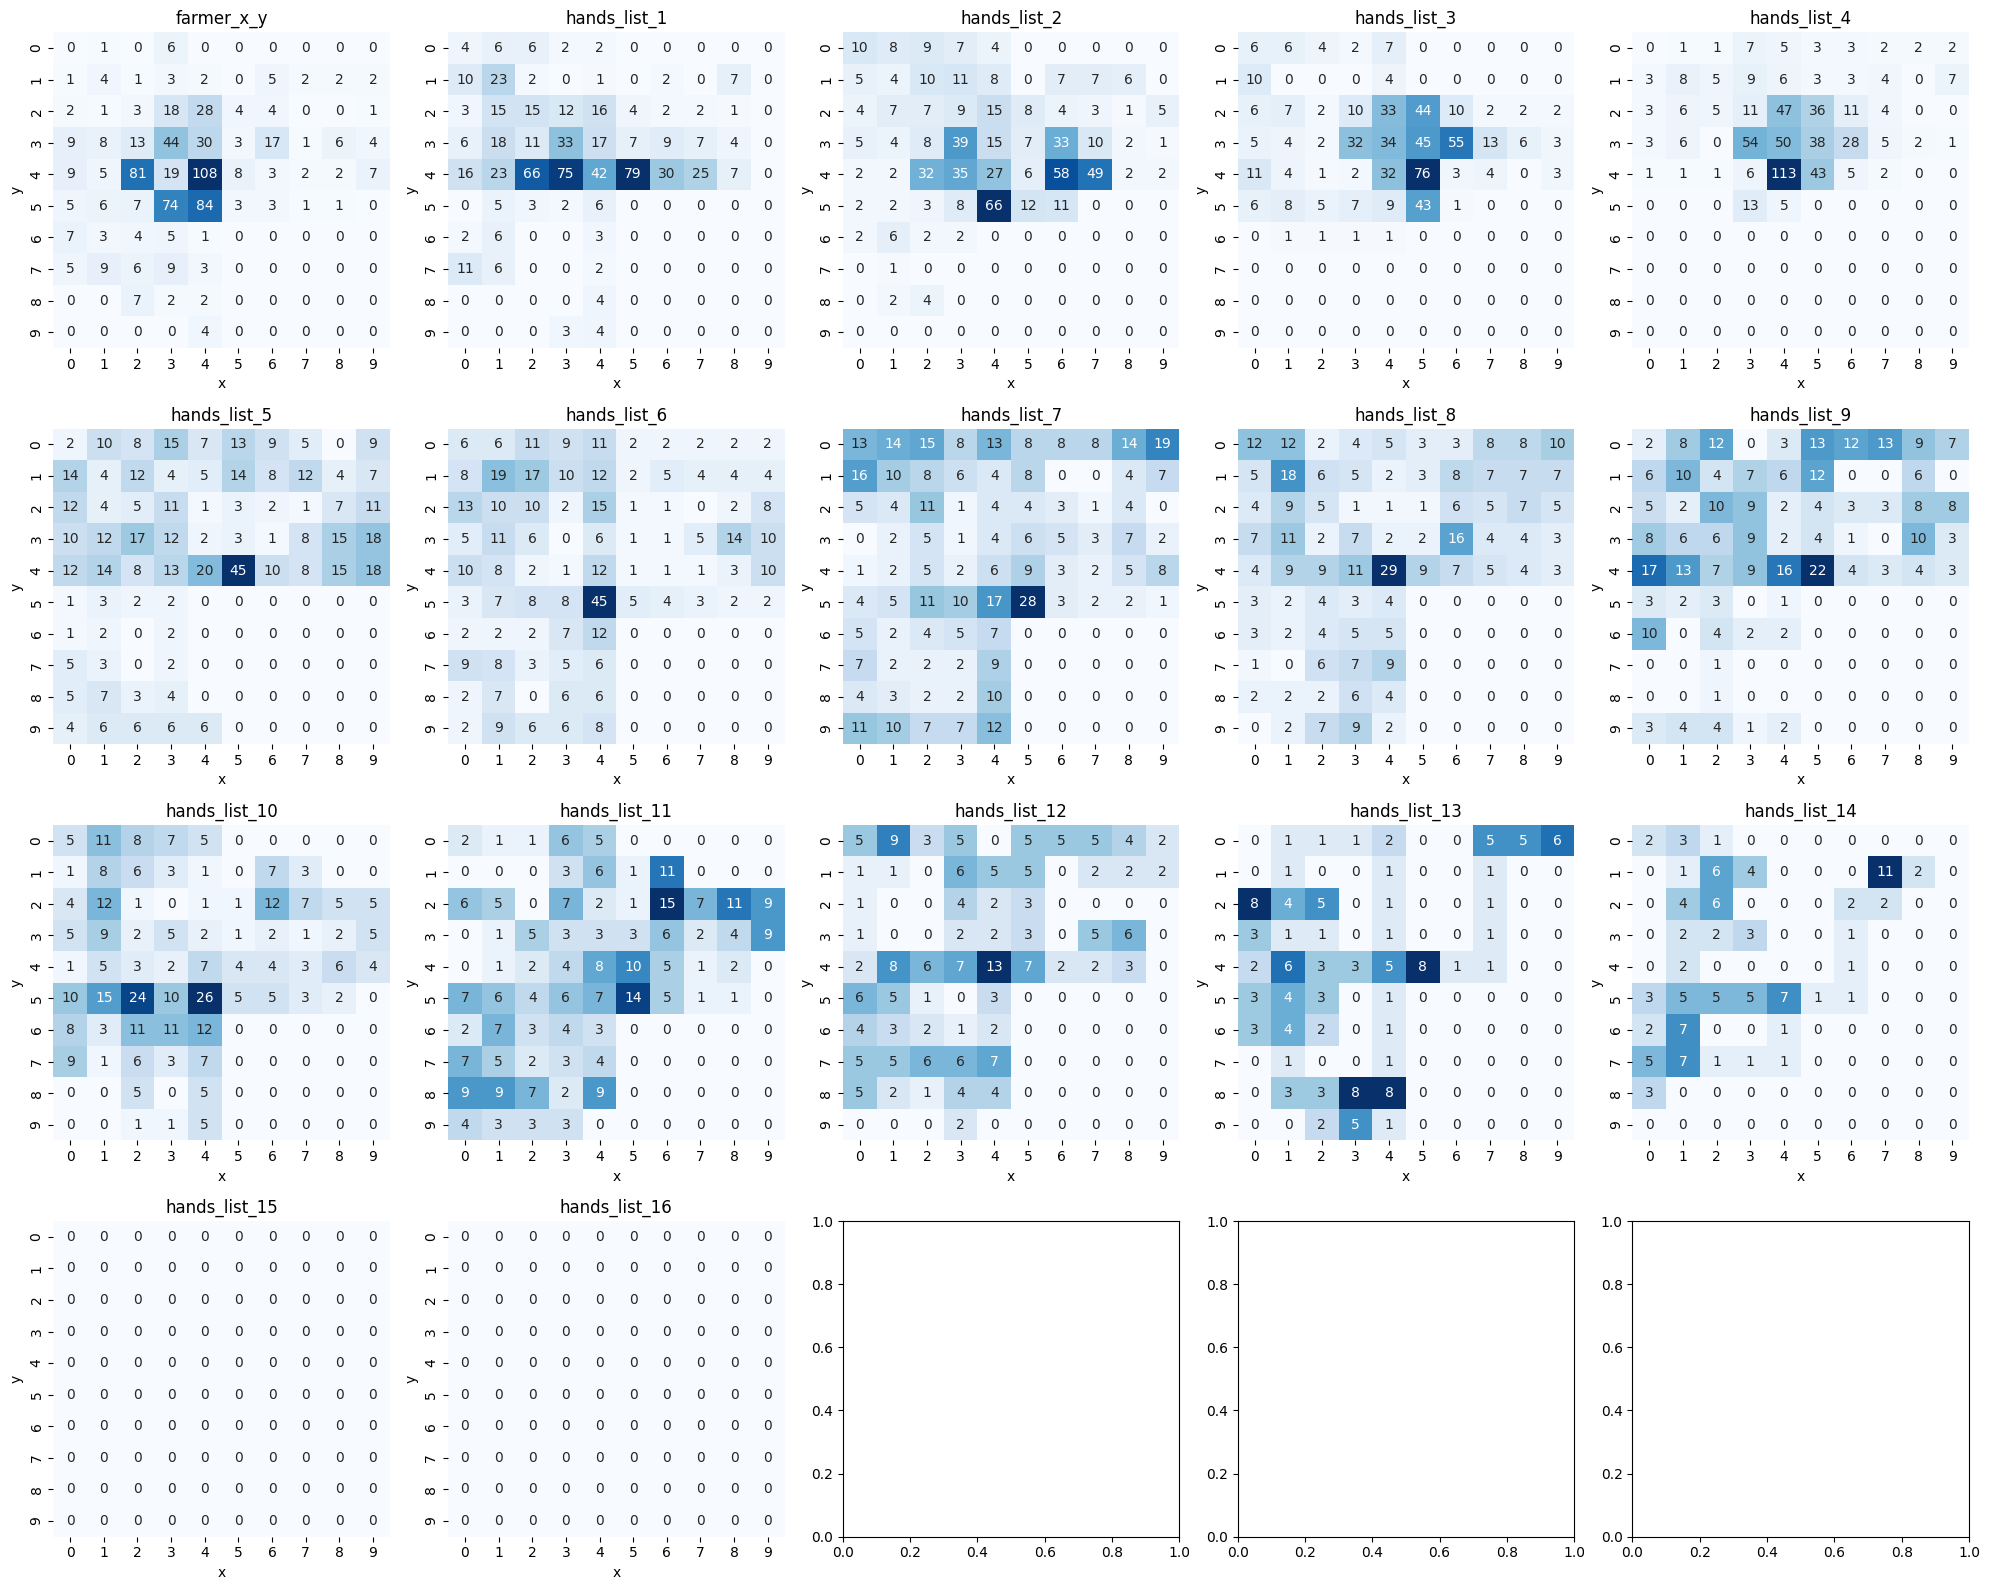

In [ ]:
cols_be = ["farmer_x_y"] + [f"hands_list_{i}" for i in range(1, 17)]
xy_plt_2d_all(df_be, cols_be, 4, 5)

In [49]:
print("上級者の最終所持金:", df_st["money"].iloc[-1])
print("初心者の最終所持金:", df_be["money"].iloc[-1])

上級者の最終所持金: 157577.0
初心者の最終所持金: 83174.0
